**Austim capstone**

In [ ]:
# importing all the libraries
!pip install numpy
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)
pd.set_option('display.max_columns',None)

In [ ]:
#loading the dataset
#reading the data
from google.colab import files


uploaded = files.upload()


Saving csv_result-Autism_Data (1).csv to csv_result-Autism_Data (1).csv



Data Preprocessing

In [ ]:
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv(io.BytesIO(uploaded['csv_result-Autism_Data (1).csv']))
print(df)

       1  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  \
0      2       NaN       NaN       NaN       NaN       NaN       NaN   
1      3       1.0       1.0       1.0       1.0       0.0       0.0   
2      4       1.0       1.0       0.0       1.0       0.0       0.0   
3      5       1.0       1.0       0.0       1.0       1.0       0.0   
4      6       1.0       1.0       0.0       1.0       0.0       0.0   
..   ...       ...       ...       ...       ...       ...       ...   
700  702       0.0       1.0       0.0       1.0       1.0       0.0   
701  703       1.0       0.0       0.0       0.0       0.0       0.0   
702  704       1.0       0.0       1.0       1.0       1.0       0.0   
703  705       1.0       0.0       0.0       1.0       1.0       0.0   
704  706       1.0       0.0       1.0       1.0       1.0       0.0   

     A7_Score  A8_Score  A9_Score  A10_Score  age gender       ethnicity  \
0         NaN       NaN       NaN        NaN  NaN    NaN   

survey questions

A1 -> Does your child look at you when you call his/her name?

A2 -> How easy is it for you to get eye contact with your child?

A3 -> Does your child point to indicate that s/he wants something? (e.g. a toy that is out of reach)

A4 -> Does your child point to share interest with you? (e.g. poin9ng at an interesing sight)

A5 -> Does your child pretend? (e.g. care for dolls, talk on a toy phone)

A6 -> Does your child follow where you’re looking?

A7 -> If you or someone else in the family is visibly upset, does your child show signs of comforting them? (e.g. stroking hair, hugging them)

A8 -> Would you describe your child’s first words as:

A9 -> Does your child use simple gestures? (e.g. wave goodbye)

A10 -> Does your child stare at nothing with no apparent purpose?

In [ ]:
display(df.shape)

(705, 22)

In [ ]:
df.head()

,1,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,26,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
2,4,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,24,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
3,5,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,27,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
4,6,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,35,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO


In [ ]:
df.tail()

,1,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
700,702,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,25,f,White-European,no,no,Russia,no,7.0,18 and more,Self,YES
701,703,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,34,m,Hispanic,no,no,Mexico,no,3.0,18 and more,Parent,NO
702,704,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,24,f,?,no,no,Russia,no,7.0,18 and more,?,YES
703,705,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,35,m,South Asian,no,no,Pakistan,no,6.0,18 and more,Self,NO
704,706,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,26,f,White-European,no,no,Cyprus,no,8.0,18 and more,Self,YES


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   1                705 non-null    int64  
 1   A1_Score         704 non-null    float64
 2   A2_Score         704 non-null    float64
 3   A3_Score         704 non-null    float64
 4   A4_Score         704 non-null    float64
 5   A5_Score         704 non-null    float64
 6   A6_Score         704 non-null    float64
 7   A7_Score         704 non-null    float64
 8   A8_Score         704 non-null    float64
 9   A9_Score         704 non-null    float64
 10  A10_Score        704 non-null    float64
 11  age              704 non-null    object 
 12  gender           704 non-null    object 
 13  ethnicity        704 non-null    object 
 14  jundice          704 non-null    object 
 15  austim           704 non-null    object 
 16  contry_of_res    704 non-null    object 
 17  used_app_before 

Replacing the ? and finding the dtypes

In [ ]:
#replacing the ? and dtypes
df["age"].value_counts()


21     49
20     46
23     37
22     37
19     35
24     34
27     31
18     31
30     30
26     28
25     27
29     27
28     24
31     21
17     18
32     18
35     17
37     17
33     16
40     16
42     15
36     13
38     12
34     12
43     11
44     10
47      8
39      7
55      6
53      6
46      6
50      5
52      5
48      4
45      4
49      3
41      3
54      2
58      2
?       2
56      2
61      2
59      1
64      1
60      1
383     1
51      1
Name: age, dtype: int64

In [ ]:
df["age"].replace("?",np.nan,inplace= True)
df["age"]= df["age"].astype("float")
df["age"].mean()
df["age"].fillna(df["age"].mean(),inplace = True)

In [ ]:
df["ethnicity"].value_counts()

White-European     233
Asian              123
?                   95
Middle Eastern      92
Black               43
South Asian         36
Others              30
Latino              20
Hispanic            13
Pasifika            12
Turkish              6
others               1
Name: ethnicity, dtype: int64

In [ ]:
df["ethnicity"] = df["ethnicity"].astype("category")
df["ethnicity"] = df["ethnicity"].cat.codes
df["ethnicity"].fillna(df["ethnicity"].mean(), inplace=True)
df["ethnicity"].dtypes

dtype('int8')

In [ ]:
df["age_desc"].value_counts()

18 and more    704
Name: age_desc, dtype: int64

In [ ]:
df["age_desc"] = df["age_desc"].astype("category")
df["age_desc"] = df["age_desc"].cat.codes
df["age_desc"].fillna(df["age_desc"].mean(), inplace=True)

In [ ]:
df["relation"].value_counts()

Self                        522
?                            95
Parent                       50
Relative                     28
Others                        5
Health care professional      4
Name: relation, dtype: int64

In [ ]:
df["relation"].replace("?",np.nan,inplace= True)
df["relation"]= df["age"].astype("category")

In [ ]:
df["jundice"] = df["jundice"].astype("category")
df["jundice"] = df["jundice"].cat.codes
df["jundice"].fillna(df["jundice"].mean(), inplace=True)

In [ ]:
df["austim"] = df["austim"].astype("category")
df["austim"] = df["austim"].cat.codes
df["austim"].fillna(df["austim"].mean(), inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   1                705 non-null    int64   
 1   A1_Score         704 non-null    float64 
 2   A2_Score         704 non-null    float64 
 3   A3_Score         704 non-null    float64 
 4   A4_Score         704 non-null    float64 
 5   A5_Score         704 non-null    float64 
 6   A6_Score         704 non-null    float64 
 7   A7_Score         704 non-null    float64 
 8   A8_Score         704 non-null    float64 
 9   A9_Score         704 non-null    float64 
 10  A10_Score        704 non-null    float64 
 11  age              705 non-null    float64 
 12  gender           704 non-null    object  
 13  ethnicity        705 non-null    int8    
 14  jundice          705 non-null    int8    
 15  austim           705 non-null    int8    
 16  contry_of_res    704 non-null    object  
 1

Droping the columns and setting value for the target

In [ ]:
AustimDf = df.drop('1',axis=1)
AustimDf = df.drop('age_desc',axis=1)
AustimDf['Class/ASD'] = np.where(AustimDf['Class/ASD']=="YES",1,0)
AustimDf.head()

,1,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.698006,NaN,-1,-1,-1,NaN,NaN,NaN,29.698006,0
1,3,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,26.000000,f,10,0,0,United States,no,6.0,26.000000,0
2,4,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,24.000000,m,4,0,1,Brazil,no,5.0,24.000000,0
3,5,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,27.000000,m,4,1,1,Spain,no,8.0,27.000000,1
4,6,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,35.000000,f,10,0,1,United States,no,6.0,35.000000,0


Feature Selection with Correlation Method

In [ ]:
corr = AustimDf.corr()
corr

<ipython-input-23-8b0ade971741>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = AustimDf.corr()


,1,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,ethnicity,jundice,austim,result,Class/ASD
1,1.000000,0.066290,0.047746,0.032943,0.012728,0.037583,-0.060366,0.043043,-0.035348,0.012815,0.017795,-0.045024,-0.038336,0.082318,-0.058346,0.034795,0.041129
A1_Score,0.066290,1.000000,0.011539,0.074096,0.127814,0.169369,0.110199,0.217538,0.147640,0.145452,0.118413,0.022974,0.141182,-0.019077,0.097630,0.397454,0.297628
A2_Score,0.047746,0.011539,1.000000,0.223921,0.158998,0.153821,0.185864,-0.041768,0.035408,0.205421,0.068883,0.020793,0.189452,0.112615,0.074555,0.392540,0.311382
A3_Score,0.032943,0.074096,0.223921,1.000000,0.412722,0.264927,0.268846,0.078216,0.017771,0.315113,0.168454,0.029468,0.204449,0.061760,0.113697,0.552356,0.441074
A4_Score,0.012728,0.127814,0.158998,0.412722,1.000000,0.306806,0.295152,0.151236,0.008617,0.327673,0.210968,0.032493,0.236456,0.064918,0.193820,0.586025,0.469945
A5_Score,0.037583,0.169369,0.153821,0.264927,0.306806,1.000000,0.392354,0.238589,0.102086,0.396582,0.267561,-0.025060,0.125808,0.034378,0.090009,0.639706,0.537004
A6_Score,-0.060366,0.110199,0.185864,0.268846,0.295152,0.392354,1.000000,0.175489,0.100123,0.479422,0.294435,0.034686,0.210185,0.078366,0.114048,0.630012,0.592091
A7_Score,0.043043,0.217538,-0.041768,0.078216,0.151236,0.238589,0.175489,1.000000,0.085403,0.189480,0.252107,-0.026493,0.046588,0.030850,-0.008610,0.454848,0.351429
A8_Score,-0.035348,0.147640,0.035408,0.017771,0.008617,0.102086,0.100123,0.085403,1.000000,0.101733,0.100782,-0.080225,0.028065,0.012101,0.034845,0.324020,0.237161
A9_Score,0.012815,0.145452,0.205421,0.315113,0.327673,0.396582,0.479422,0.189480,0.101733,1.000000,0.283340,0.053967,0.156265,0.057717,0.167644,0.661205,0.635576


<Axes: >

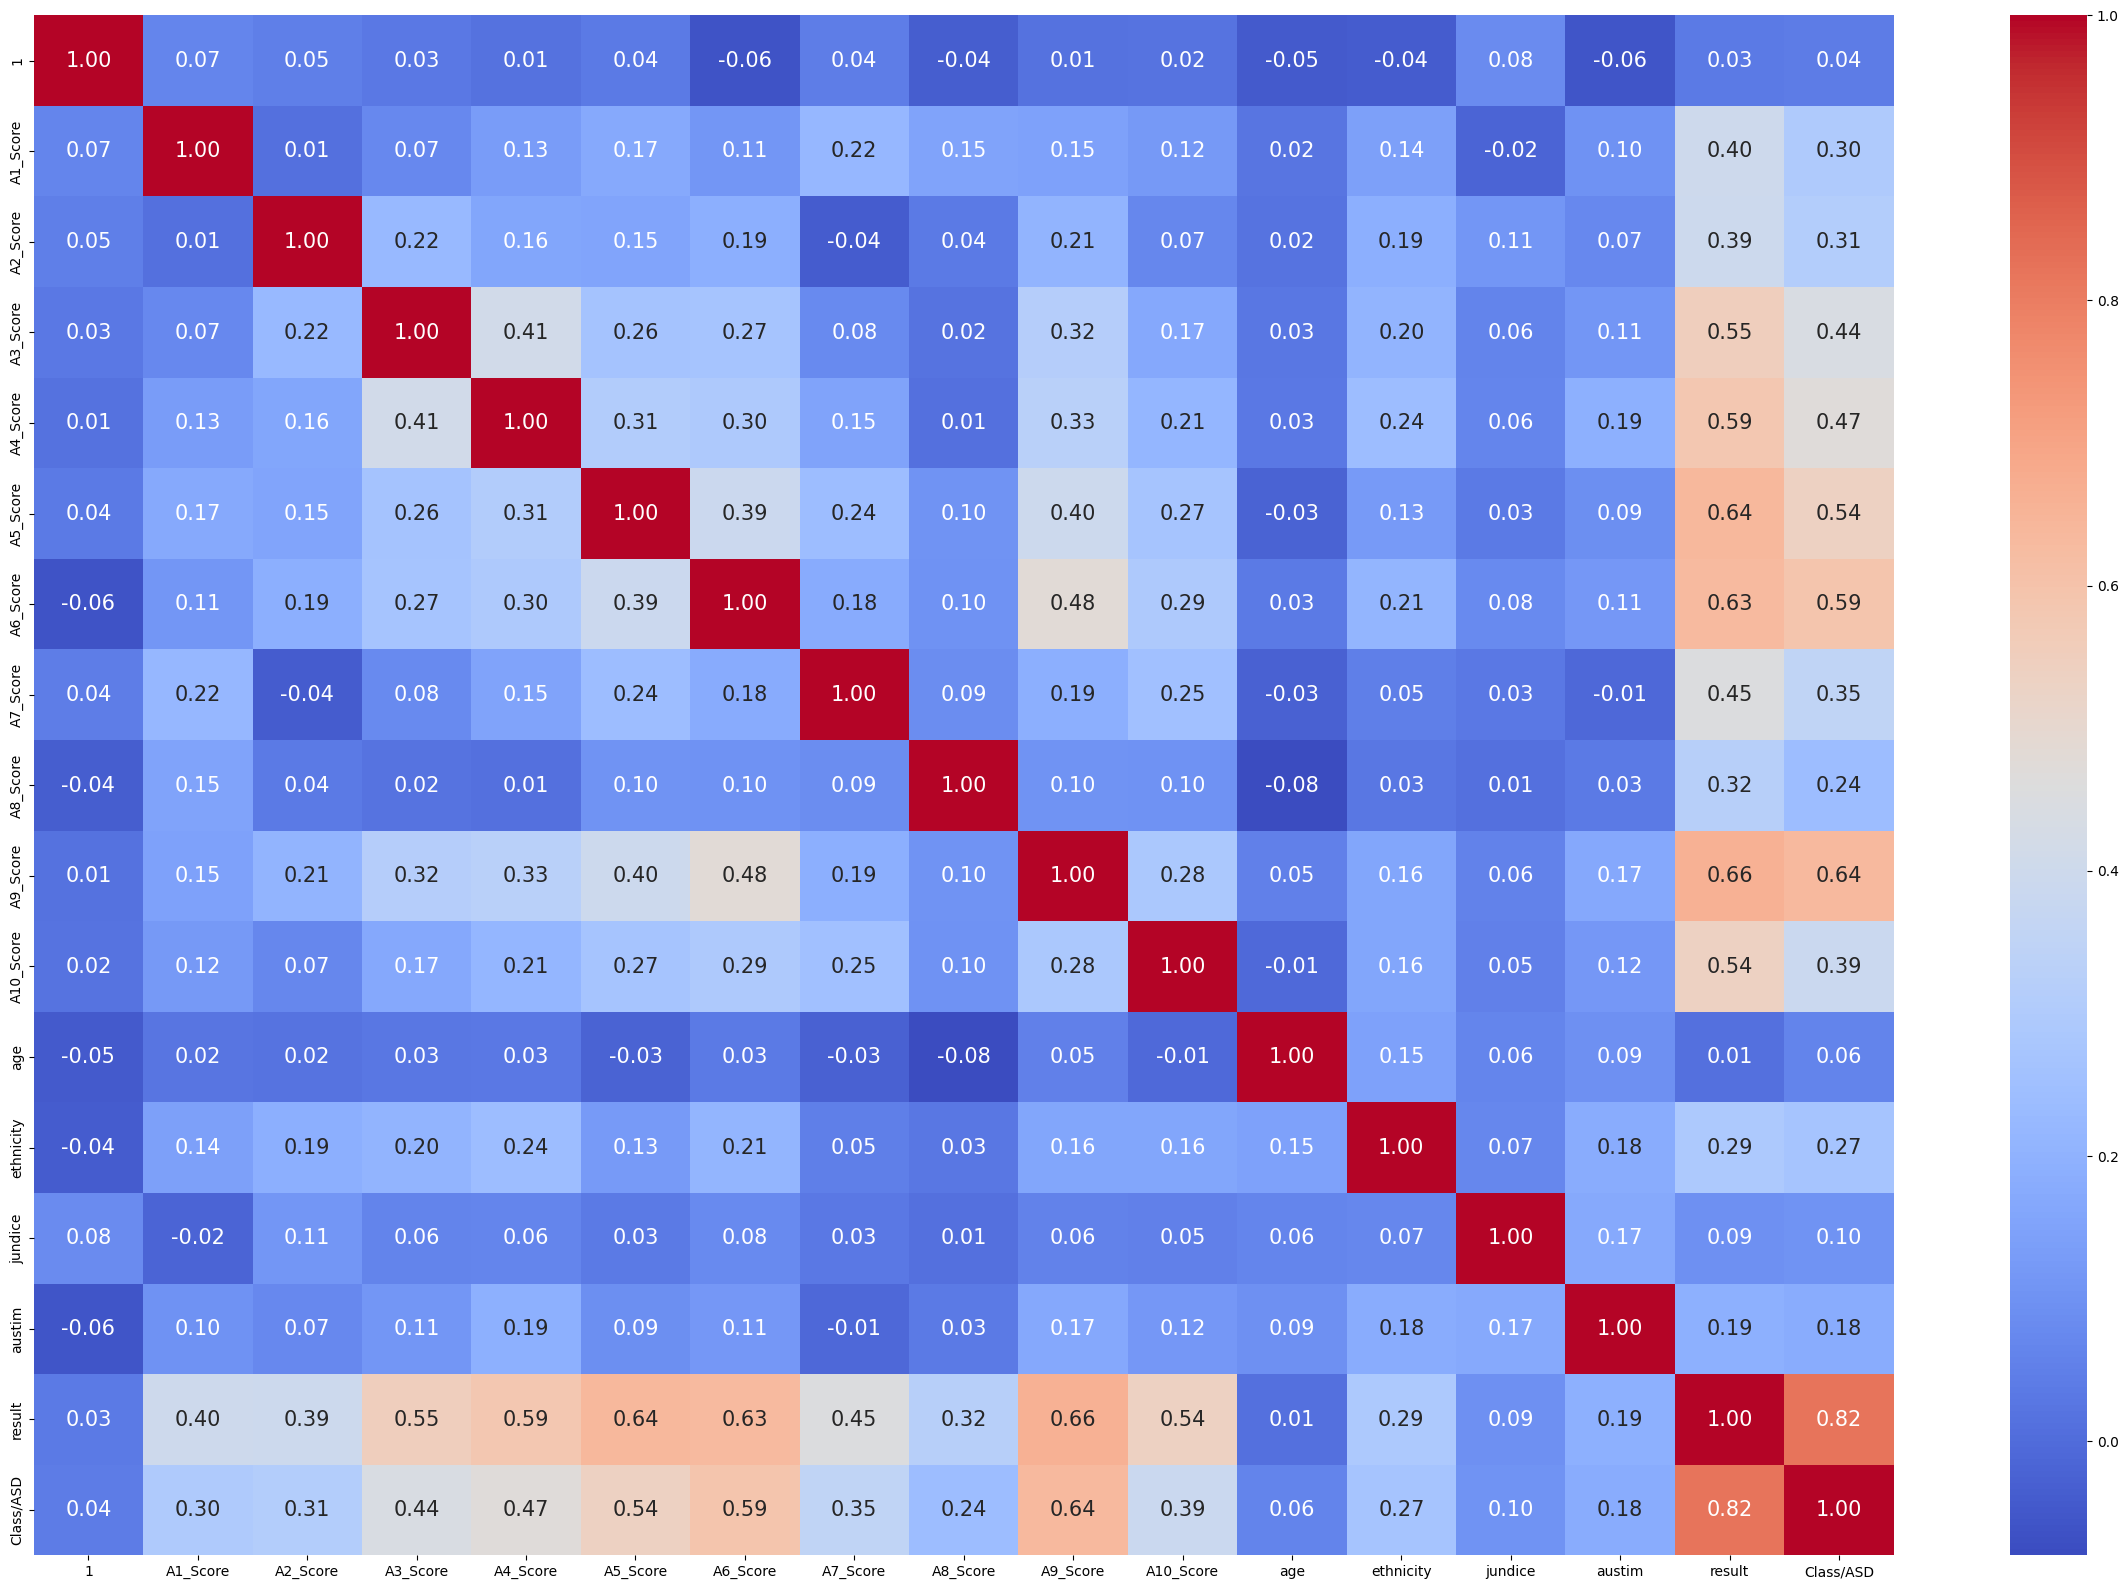

In [ ]:
plt.figure(figsize=(30,20))
sns.heatmap(corr,annot=True,fmt='.2f',annot_kws=dict(size=15),cmap='coolwarm')

One Hot Encoding >>>> Change columns with words to numbers

In [ ]:
df_encoded = pd.get_dummies(df, columns=['gender','austim','jundice','age_desc','Class/ASD'])

In [ ]:
df_encoded.shape

(705, 29)

Finding the null values

In [ ]:
df_encoded.isnull()

,1,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,ethnicity,contry_of_res,used_app_before,result,relation,gender_f,gender_m,austim_-1,austim_0,austim_1,jundice_-1,jundice_0,jundice_1,age_desc_-1,age_desc_0,Class/ASD_NO,Class/ASD_YES
0,False,True,True,True,True,True,True,True,True,True,True,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
701,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
702,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
703,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_encoded.isnull().sum()

1                  0
A1_Score           1
A2_Score           1
A3_Score           1
A4_Score           1
A5_Score           1
A6_Score           1
A7_Score           1
A8_Score           1
A9_Score           1
A10_Score          1
age                0
ethnicity          0
contry_of_res      1
used_app_before    1
result             1
relation           0
gender_f           0
gender_m           0
austim_-1          0
austim_0           0
austim_1           0
jundice_-1         0
jundice_0          0
jundice_1          0
age_desc_-1        0
age_desc_0         0
Class/ASD_NO       0
Class/ASD_YES      0
dtype: int64

In [ ]:
df_encoded.isnull().sum().sum()

13

Filling null values

In [ ]:
df2=df_encoded.fillna(df_encoded.mean())
df2

<ipython-input-528-1c8b5c7ddae1>:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2=df_encoded.fillna(df_encoded.mean())


,1,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,ethnicity,contry_of_res,used_app_before,result,relation,gender_f,gender_m,austim_-1,austim_0,austim_1,jundice_-1,jundice_0,jundice_1,age_desc_-1,age_desc_0,Class/ASD_NO,Class/ASD_YES
0,2,0.721591,0.453125,0.457386,0.495739,0.49858,0.284091,0.417614,0.649148,0.323864,0.573864,29.698006,-1,NaN,NaN,4.875,29.698006,0,0,1,0,0,1,0,0,1,0,0,0
1,3,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,26.000000,10,United States,no,6.000,26.000000,1,0,0,1,0,0,1,0,0,1,1,0
2,4,1.000000,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,4,Brazil,no,5.000,24.000000,0,1,0,0,1,0,1,0,0,1,1,0
3,5,1.000000,1.000000,0.000000,1.000000,1.00000,0.000000,1.000000,1.000000,1.000000,1.000000,27.000000,4,Spain,no,8.000,27.000000,0,1,0,0,1,0,0,1,0,1,0,1
4,6,1.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,1.000000,0.000000,1.000000,35.000000,10,United States,no,6.000,35.000000,1,0,0,0,1,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,702,0.000000,1.000000,0.000000,1.000000,1.00000,0.000000,1.000000,1.000000,1.000000,1.000000,25.000000,10,Russia,no,7.000,25.000000,1,0,0,1,0,0,1,0,0,1,0,1
701,703,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,1.000000,34.000000,3,Mexico,no,3.000,34.000000,0,1,0,1,0,0,1,0,0,1,1,0
702,704,1.000000,0.000000,1.000000,1.000000,1.00000,0.000000,1.000000,1.000000,0.000000,1.000000,24.000000,0,Russia,no,7.000,24.000000,1,0,0,1,0,0,1,0,0,1,0,1
703,705,1.000000,0.000000,0.000000,1.000000,1.00000,0.000000,1.000000,0.000000,1.000000,1.000000,35.000000,8,Pakistan,no,6.000,35.000000,0,1,0,1,0,0,1,0,0,1,1,0


In [ ]:
df2.dtypes

1                     int64
A1_Score            float64
A2_Score            float64
A3_Score            float64
A4_Score            float64
A5_Score            float64
A6_Score            float64
A7_Score            float64
A8_Score            float64
A9_Score            float64
A10_Score           float64
age                 float64
ethnicity              int8
contry_of_res        object
used_app_before      object
result              float64
relation           category
gender_f              uint8
gender_m              uint8
austim_-1             uint8
austim_0              uint8
austim_1              uint8
jundice_-1            uint8
jundice_0             uint8
jundice_1             uint8
age_desc_-1           uint8
age_desc_0            uint8
Class/ASD_NO          uint8
Class/ASD_YES         uint8
dtype: object

In [ ]:
df2.isnull()

,1,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,ethnicity,contry_of_res,used_app_before,result,relation,gender_f,gender_m,austim_-1,austim_0,austim_1,jundice_-1,jundice_0,jundice_1,age_desc_-1,age_desc_0,Class/ASD_NO,Class/ASD_YES
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
701,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
702,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
703,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df2.isnull().sum()

1                  0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
ethnicity          0
contry_of_res      1
used_app_before    1
result             0
relation           0
gender_f           0
gender_m           0
austim_-1          0
austim_0           0
austim_1           0
jundice_-1         0
jundice_0          0
jundice_1          0
age_desc_-1        0
age_desc_0         0
Class/ASD_NO       0
Class/ASD_YES      0
dtype: int64

Providing the input and output data

In [ ]:
# Assuming df2 is your DataFrame
columns = ["A1_Score", "A2_Score", "A3_Score", "A4_Score", "A5_Score", "A6_Score", "A7_Score", "A8_Score", "A9_Score", "A10_Score","austim_-1","austim_0","austim_1","jundice_-1","jundice_0","jundice_1","age_desc_-1","age_desc_0"]
x = np.array(df2[columns])


In [ ]:
x.shape

(705, 18)

In [ ]:
print(x)

[[0.72159091 0.453125   0.45738636 ... 0.         1.         0.        ]
 [1.         1.         1.         ... 0.         0.         1.        ]
 [1.         1.         0.         ... 0.         0.         1.        ]
 ...
 [1.         0.         1.         ... 0.         0.         1.        ]
 [1.         0.         0.         ... 0.         0.         1.        ]
 [1.         0.         1.         ... 0.         0.         1.        ]]


In [ ]:
#The output data (y,predictor)
y = np.array(df2["Class/ASD_NO"])

In [ ]:
y.shape

(705,)

In [ ]:
print(y)

[0 1 1 0 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1
 1 1 0 0 0 1 1 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 0 1 1 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 0 1 1 0 0 0 1 1 1 1 1 0 0 0 1 1 1
 0 0 0 1 0 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1
 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 1 1 0 1 

In [ ]:
print(type(y))

<class 'numpy.ndarray'>


Splitting the dataset

In [ ]:
# Import train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=12)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

Exploring the train and test datasets

In [ ]:
x_train.shape

(564, 18)

In [ ]:
x_test.shape

(141, 18)

In [ ]:
y.shape

(705,)

In [ ]:
print(y_train.shape)

(564,)


In [ ]:
print(y_test.shape)

(141,)


Model

In [ ]:
# Define the train model
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix
def train_model(model, x_train, y_train, x_test, y_test):

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

In [ ]:
# Artificial Neural Networks
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
model = Sequential()

In [ ]:
# Adding input layer
model.add(Dense(64, activation="relu", input_dim=18))
# Adding First Hidden Layer
model.add(Dense(64, activation="relu"))
# Adding Output Layer
model.add(Dense(1, activation="sigmoid"))

In [ ]:
model.compile(optimizer="Adam", loss="binary_crossentropy", metrics=["accuracy"])
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=None
)
train = model.fit(x_train, y_train, batch_size=20, epochs=30, validation_split=0.2, callbacks=callback)

Epoch 1/30
23/23 [==============================] - 1s 13ms/step - loss: 0.5846 - accuracy: 0.7339 - val_loss: 0.5204 - val_accuracy: 0.7345
Epoch 2/30
23/23 [==============================] - 0s 4ms/step - loss: 0.4500 - accuracy: 0.7716 - val_loss: 0.3993 - val_accuracy: 0.8673
Epoch 3/30
23/23 [==============================] - 0s 5ms/step - loss: 0.3174 - accuracy: 0.9002 - val_loss: 0.2625 - val_accuracy: 0.9027
Epoch 4/30
23/23 [==============================] - 0s 4ms/step - loss: 0.2092 - accuracy: 0.9512 - val_loss: 0.1752 - val_accuracy: 0.9381
Epoch 5/30
23/23 [==============================] - 0s 4ms/step - loss: 0.1470 - accuracy: 0.9645 - val_loss: 0.1271 - val_accuracy: 0.9558
Epoch 6/30
23/23 [==============================] - 0s 4ms/step - loss: 0.1160 - accuracy: 0.9690 - val_loss: 0.1062 - val_accuracy: 0.9469
Epoch 7/30
23/23 [==============================] - 0s 4ms/step - loss: 0.0922 - accuracy: 0.9845 - val_loss: 0.0850 - val_accuracy: 0.9823
Epoch 8/30
23/23 [=

In [ ]:
model.evaluate(x_test,y_test)

5/5 [==============================] - 0s 3ms/step - loss: 0.0212 - accuracy: 1.0000


[0.021192017942667007, 1.0]

In [ ]:
y_prob = model.predict(x_test_scaled)
y_pred = np.where(y_prob > 0.5, 1, 0)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

5/5 [==============================] - 0s 3ms/step


Confusion Matrix

In [ ]:
matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix is: ")
print(matrix)

Confusion Matrix is: 
[[43  4]
 [ 0 94]]


In [ ]:
# Create a new DataFrame with the given data and column names
result = pd.DataFrame([[accuracy, precision, recall, f1]],
                     columns=['accuracy', 'precision', 'recall', 'f1'])

# Set the index of the DataFrame
result.index = ["Artificial Neural Network"]

# Display the result DataFrame
result

,accuracy,precision,recall,f1
Artificial Neural Network,0.971631,0.959184,1.0,0.979167
